# Utforskning av datasets #


In [1]:
# Importer
import numpy as np
import pandas as pd

# Hämta datan från npz filen - allow 
sequence = np.load('data/segment_sequences.npz', allow_pickle=True)

# Se vad som finns i filen
print(sequence.files)


['X_seq', 'y_seq', 'groups', 'segment_id']


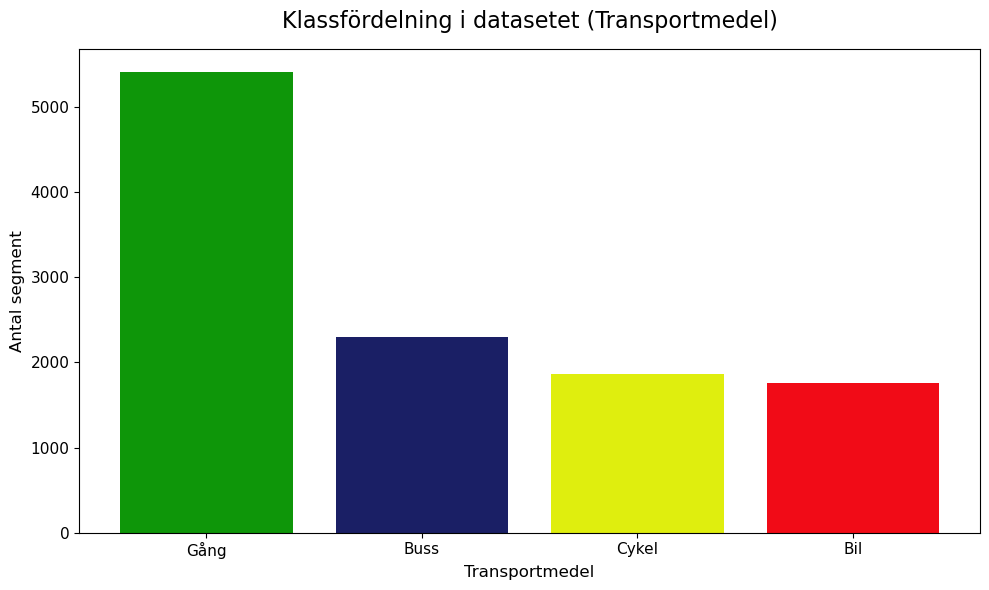

Fördelning av transportmedelel
mode
walk    5412
bus     2298
bike    1859
car     1757
Name: count, dtype: int64

Fördelning i %
mode
walk    47.783860
bus     20.289599
bike    16.413562
car     15.512979
Name: proportion, dtype: float64

Kort reflektion:
walk är väldigt överrepresenterat med ca 48 %, car lägst med ca 16 %
walk kommer ev väga för tungt i modellträningen, det återstår att se


In [2]:
# Importer
import matplotlib.pyplot as plt

# Läs in csv-filen features för att utforska. 
df_features = pd.read_csv('data/segment_features.csv', sep=None, engine='python')

# Bar chart över klassfördelningen

# Hämtar fördelningen 
counts = df_features['mode'].value_counts()

# Översätter klasserna till svesnka
swedish_labels = []
for eng_name in counts.index:
    if eng_name == 'walk': swedish_labels.append('Gång')
    elif eng_name == 'car': swedish_labels.append('Bil')
    elif eng_name == 'bus': swedish_labels.append('Buss')
    elif eng_name == 'bike': swedish_labels.append('Cykel')
    else: swedish_labels.append(str(eng_name)) # Fallback om det är något annat

# Skapar diagrammet
plt.figure(figsize=(10, 6))

# ritar staplarna med de svenska namnen på X-axeln
plt.bar(swedish_labels, counts.values, color=["#0E9609", "#1a1f65", "#dfee0e", "#f10b17"])

# Rubriker och etiketter
plt.title('Klassfördelning i datasetet (Transportmedel)', fontsize=16, pad=15)
plt.xlabel('Transportmedel', fontsize=12)
plt.ylabel('Antal segment', fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

# Vi kollar hur klassfördelningen ser ut mer exakt. (mode)
print("Fördelning av transportmedelel")
print(df_features['mode'].value_counts())
print()

# I procent
print("Fördelning i %")
print(df_features['mode'].value_counts(normalize=True) * 100)
print()
print("Kort reflektion:")
print("walk är väldigt överrepresenterat med ca 48 %, car lägst med ca 16 %")
print("walk kommer ev väga för tungt i modellträningen, det återstår att se")

In [3]:
# Läs in csv-filen metadata för att utforska. 
df_metadata = pd.read_csv('data/segment_metadata.csv', sep=None, engine='python')

# Visa de första raderna så man får en överblick
df_metadata.head()

,segment_id,user_id,file_name,mode
0,0,10,20080331160008.plt,car
1,1,10,20080331160008.plt,car
2,2,10,20080402060926.plt,walk
3,3,10,20080402060926.plt,car
4,4,10,20080402060926.plt,bus


### Kommentar ###

**.npz filen:**  Vi har här fyra variablar: X_seq (tidssekvenserna), y_seq (målvaribeln), groups (användarID) och segment_id (id för varje unik resa).
Denna data lämpar sig att använda till en Deep learning modell.

**feature filen:** Här har vi all data vi behöver. features, targets(mode) och alla userId:s och segmentsID:s. Denn använder vi för att träna våra enklare modeller.

**metadata filen:** Här har vi samma data som i featuredatan förutom alla features. Denna fil kommer vi inte använda.

**Klassfördelningen:** Är lite skev, walk väger nog lite för tungt i datasetet mot de andra transportmedlen. Vi behöver nog ta hänsyn till det när vi splittar datan sen.



# Task 1: Feature engineering and Machine Learning Model #


### Korrrelationsanalys ###

Targets i siffror:
{0: 'bike', 1: 'bus', 2: 'car', 3: 'walk'}


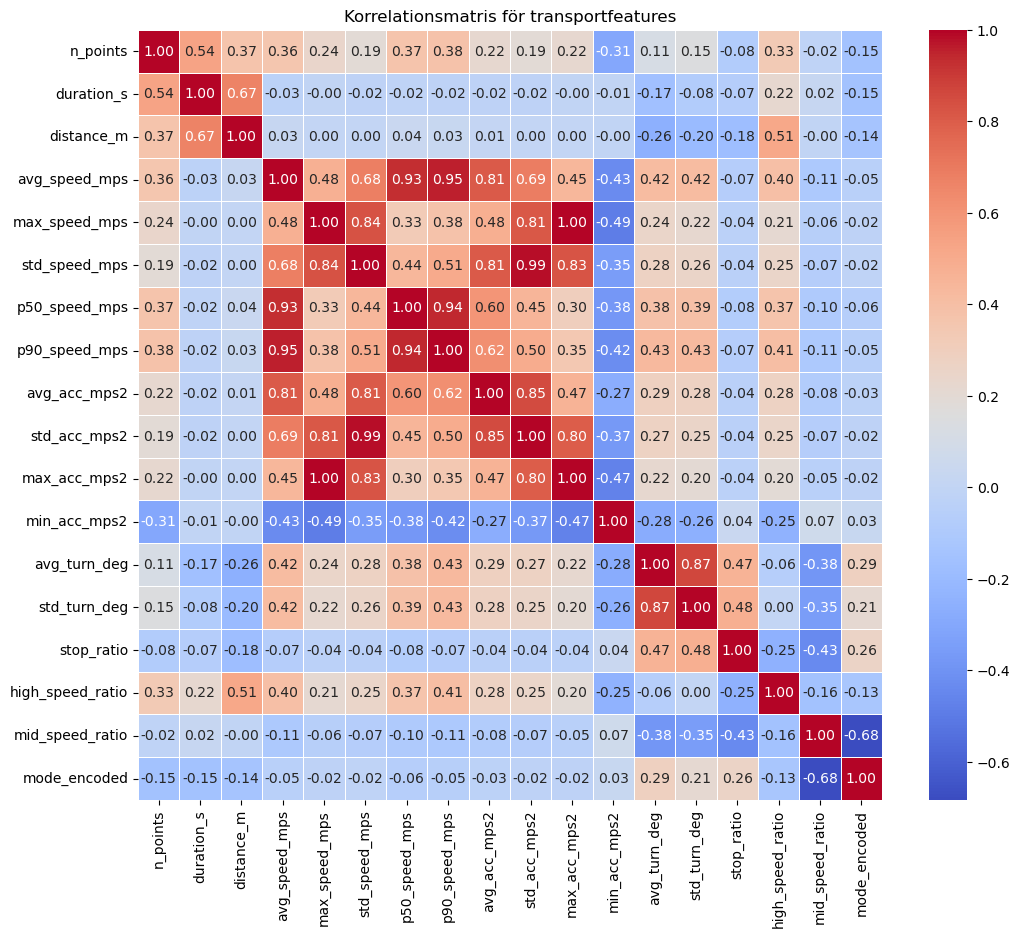


Kommentar: Vi ser tydligt att fart featuresena korrelerar högt, över 93 %. Så där har vi redundans och kan slå ihop eller tar bort nån feature
mid_speed_ratio som ser ut som att det är någon medelelåg hastighetsfeature i filen har ett ganska starkt negativtsamband med målvariabeln (mode_encoded) vilket visar att den kan påverka ganska mycket i träningen.frmaförallt i mellanfart vilket då bör vara cykel.


In [4]:
# import
import seaborn as sns


# Vi gör en korrealtionsanalys av alla features för att se vilka som ser relevanta ut, och
# ifall vi hittar redundans. Gör det enklare att välja/göra nya features.

# Va tar bort kolumneran segement, id och filnamn då dessa inte är features. Vi låter mode(target) vara kvar. 
df_features_test = df_features.drop(columns=['segment_id', 'user_id', 'file_name'])
# Sen konverterar vi mode(target) till siffror.
df_features_test['mode_encoded'] = df_features_test['mode'].astype('category').cat.codes

# kollar vilka siffro alla targets fick
print("Targets i siffror:")
print(dict(enumerate(df_features_test['mode'].astype('category').cat.categories)))

# tar bort gamla mode kolumnen för att kunna räkna. Den är en string.
df_features_corr = df_features_test.drop(columns='mode')

# Räkna ut korrealtionen
corr_matrix = df_features_corr.corr()

# Ritar upp en heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korrelationsmatris för transportfeatures')
plt.show()
print()
print("Kommentar: Vi ser tydligt att fart featuresena korrelerar högt, över 93 %. Så där har vi redundans och kan slå ihop eller tar bort nån feature")
print("mid_speed_ratio som ser ut som att det är någon medelelåg hastighetsfeature i filen har ett ganska starkt negativt" \
"samband med målvariabeln (mode_encoded) vilket visar att den kan påverka ganska mycket i träningen." \
"frmaförallt i mellanfart vilket då bör vara cykel.") 


### Feature engineering ###

In [5]:
# Väljer ut de features vi vill ha med, baserat på exempel från instruktion och korrealtionsmatrisdes
# Skapar en ny dataframe för nya/valda features

df_final = pd.DataFrame()
# target/målvariabel
df_final['mode'] = df_features['mode']

# Speed - Använder BARA avg för det hade hög korr mot de andra "speed" featuresena. Så vi undviker redundans
df_final['Speed'] = df_features['avg_speed_mps']

# Mellanfart - Läggs till för att det hade högt negativt samband med målvariabel från korr matrisen. Så är troligtvis bra att ha med.
df_final['Mellanfart'] = df_features['mid_speed_ratio']

# Acceleration väljer ut max bara för tror det ger mest. Bör ju kunna skilja på gång och bil tydligt t ex. 
df_final['Max accelaration'] = df_features['max_acc_mps2']

# Distance
df_final['Distance'] = df_features['distance_m']

# Turning angle
df_final['Turning angle'] = df_features['avg_turn_deg']

# Stop ratio
df_final['Stop ratio'] = df_features['stop_ratio']


### Splitta datan och feature important plot ###


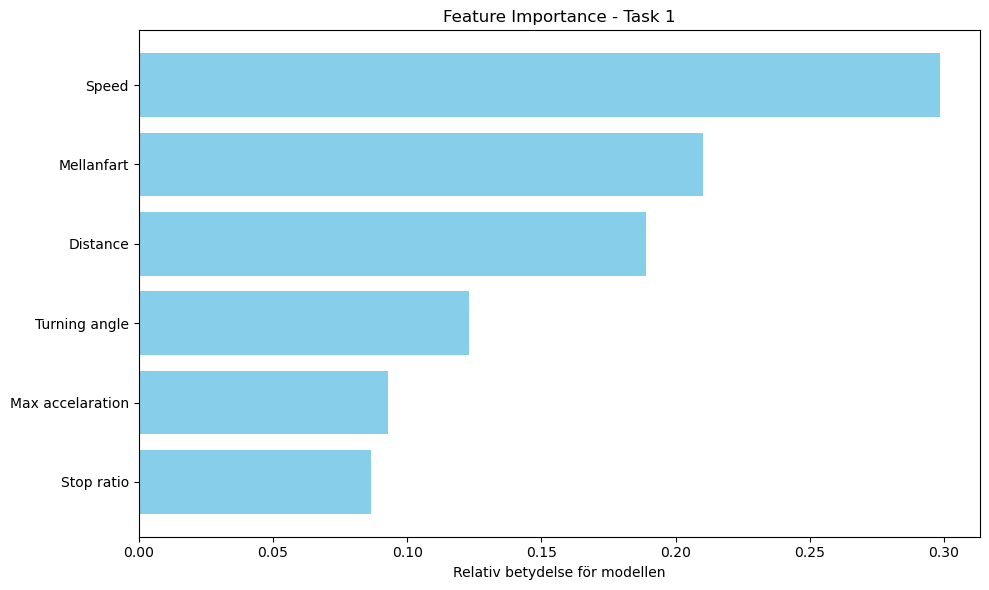

In [6]:
# Import
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Splittar features med target, X = fearures och y = target
X = df_final.drop('mode', axis=1)
y = df_final['mode']

# Splittar träningsdata med testdata - 80/20.
# Anävnder stratify för att få samma fördelning av trsnsportmedel mellan träningsdata och testdata. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Tränar Random Forest för att få Feature Importance med random_state för reproducerbarhet
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Generera Feature Importance Plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importance - Task 1')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relativ betydelse för modellen')
plt.tight_layout()
plt.show()



Kommentar: Speed hade absolut störst påverkan på modellen, ca 30 %

"Mellanfart" kom efter på dryga 20 % och distans på knappa 20 %.


# Task 2: Models to classify mobility modes #


### Random forest ###

Här har vi redan tränat modellen för att få ut en importance plot. Nu utvärderar vi

              precision    recall  f1-score   support

        bike       0.91      0.80      0.85       372
         bus       0.73      0.66      0.69       460
         car       0.77      0.69      0.73       351
        walk       0.86      0.96      0.91      1083

    accuracy                           0.83      2266
   macro avg       0.82      0.78      0.79      2266
weighted avg       0.83      0.83      0.83      2266

Snabbkommentar: Den är väldigt bra på cykel och gång, lite lägre på buss och bil. Enligt alla mätvärden



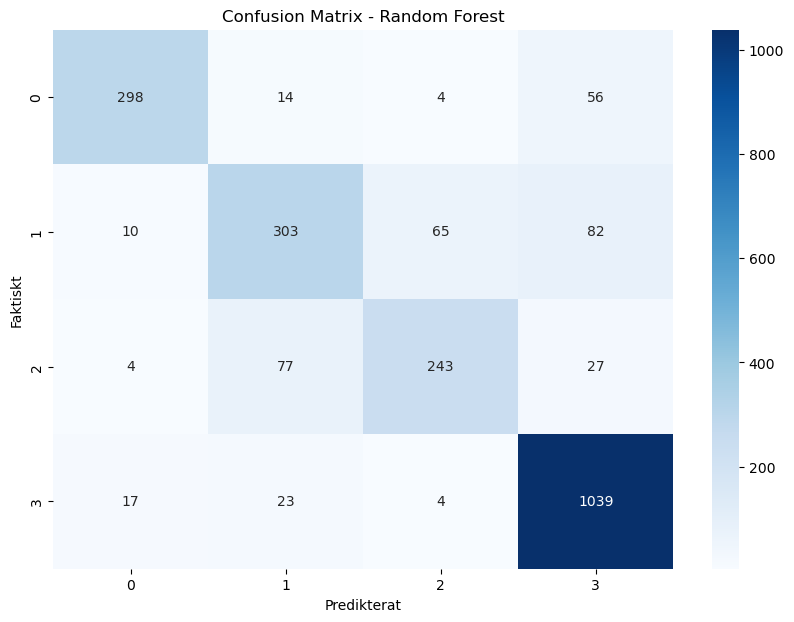

Översättning av targets:
{0: 'bike', 1: 'bus', 2: 'car', 3: 'walk'}

Snabbkommentar: Eftersom walk är överrepresenterat så kanske det hade varit snyggare och enkalre att se med procent i confusion matrixen istället. Tål att tänkas på

              precision    recall  f1-score   support

        bike       0.91      0.81      0.86       372
         bus       0.72      0.65      0.68       460
         car       0.76      0.68      0.72       351
        walk       0.87      0.96      0.91      1083

    accuracy                           0.83      2266
   macro avg       0.81      0.78      0.79      2266
weighted avg       0.83      0.83      0.83      2266

Snabbkommentar: Ingen större skilland. Konstigt nog något sämre på bus och car som den redan var sämst på.
Denna skrotar vi, kanske tom ta bort?



In [7]:
# Import
from sklearn.metrics import classification_report, confusion_matrix

# Nu testar vi modellen(rf_model) mot testdata
y_pred = rf_model.predict(X_test)

# Skriv ut en classification rapport.
print(classification_report(y_test, y_pred))
print("Snabbkommentar: Den är väldigt bra på cykel och gång, lite lägre på buss och bil. Enligt alla mätvärden")
print()

# Vi gör en confusion matrix för att visualisera tydligt
cm = confusion_matrix(y_test, y_pred)

# Rita ut den snyggt med Seaborn
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predikterat')
plt.ylabel('Faktiskt')
plt.title('Confusion Matrix - Random Forest')
plt.show()
print("Översättning av targets:")
print(dict(enumerate(df_features_test['mode'].astype('category').cat.categories)))
print()
print("Snabbkommentar: Eftersom walk är överrepresenterat så kanske det hade varit snyggare och enkalre att se med procent i " \
"confusion matrixen istället. Tål att tänkas på")
print()

# Vi testar att använda class_weight=balanced för att se om det gör skillnad då walk är så överrepresenterad.
# det gör att den lägger mer "weight" åt mindre klasser så de får mer att säga till om. Vilket väger större klassen walk som får mindre "weight"
# Balanserar upp ojämna features helt enkelt
rf_model_weight = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_weight.fit(X_train, y_train)

# Nu testar vi modellen mot testdata igen
y_pred_weight = rf_model_weight.predict(X_test)

#Skriv ut en classification rapport.
print(classification_report(y_test, y_pred_weight))
print("Snabbkommentar: Ingen större skilland. Konstigt nog något sämre på bus och car som den redan var sämst på.")
print("Denna skrotar vi, kanske tom ta bort?")
print()





SVM

In [8]:
# Importerar bibloteken vi behöver för att köra SVM modellen
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Skapa skalaren och anpassa den efter träningsdatan
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Initiera SVM-modellen
svm_model = SVC(kernel='rbf', random_state=42)

# Träna modellen på den SKALADE datan
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [10]:
# Testa modellen mot den skalade testdatan
y_pred_svm = svm_model.predict(X_test_scaled)

# Skriv ut classification report
print("--- SVM Classification Report ---")
print(classification_report(y_test, y_pred_svm))

--- SVM Classification Report ---
              precision    recall  f1-score   support

        bike       0.84      0.77      0.81       372
         bus       0.63      0.59      0.61       460
         car       0.74      0.52      0.61       351
        walk       0.83      0.95      0.89      1083

    accuracy                           0.78      2266
   macro avg       0.76      0.71      0.73      2266
weighted avg       0.78      0.78      0.77      2266



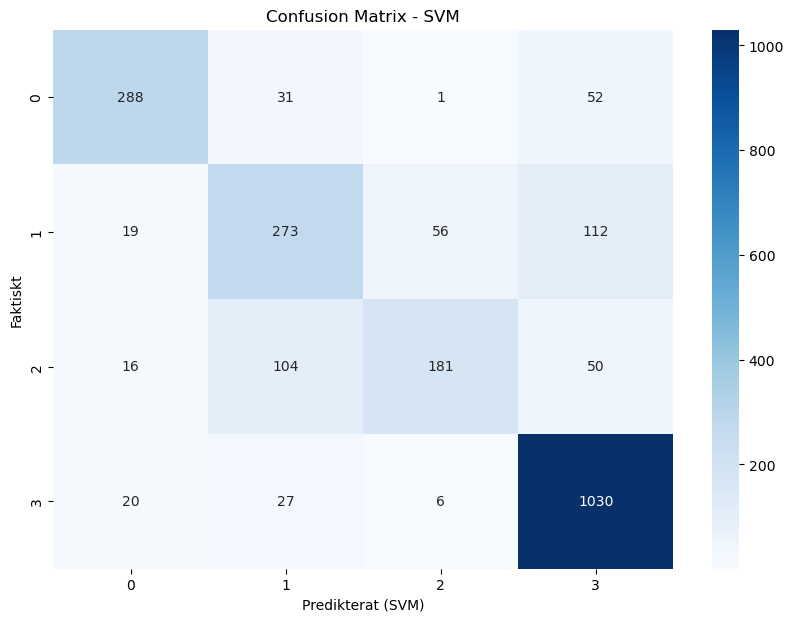

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Skriver ut en confusion matrix också
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10,7))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predikterat (SVM)')
plt.ylabel('Faktiskt')
plt.title('Confusion Matrix - SVM')
plt.show()

### Deep Learning - CNN ###


In [12]:

# Utforskar npz filen lite mer.
print(sequence.files)
# utforkar datan
print("Formen på X_seq:", sequence['X_seq'].shape)
print("Formen på y_seq:", sequence['y_seq'].shape)
print("")
print("Vad ser vi?: 11326 antal segment, 128 gps-punkter per resa, 5 olika särdrag ex hastighet, kursändring osv.")
print("Slutsats: Datafilen är förberedd för deeplearning. Rätt form från början, en 3d matris som behövs.")
print("Så det är bara att använda filen.")

['X_seq', 'y_seq', 'groups', 'segment_id']


Formen på X_seq: (11326, 128, 5)
Formen på y_seq: (11326,)

Vad ser vi?: 11326 antal segment, 128 gps-punkter per resa, 5 olika särdrag ex hastighet, kursändring osv.
Slutsats: Datafilen är förberedd för deeplearning. Rätt form från början, en 3d matris som behövs.
Så det är bara att använda filen.


In [13]:
# CNN Modell
# Baserat på: https://github.com/AmirSarrafzadeh/Transport-Mode-Detection/blob/main/005_CNN_Model.ipynb

# Importerar vad som behövs
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, MaxPooling1D, BatchNormalization, Activation
from tensorflow.keras.optimizers import RMSprop
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


# delar upp datan
X_seq = sequence['X_seq'].astype('float32')
y_seq = sequence['y_seq'].reshape(-1, 1)
groups = sequence['groups'] 

# gör om targetvaribeln till One-hot-kodad. Istället för 0,1,2,3 som det är nu blir det vektorer med nollor och en etta på alla.
# Förhindrar att modelln tror att ex klass 2 är större(matematiskt) än klass 1. 
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
y_seq_onehot = enc.fit_transform(y_seq)

# Hämtar automatiskt formen på datan (X-seq har formen 11326,128,5)
# I git-koden är siffrorna hårkodade vilket vi inte behöver 
trip_size = X_seq.shape[1]     # 128 (punkter per resa)
num_features = X_seq.shape[2]  # 5 (features)
num_class = y_seq_onehot.shape[1]    # Antal klasser: 4

#  splittar datan i tränings och testdata (80/20)
#  använder varibeln groups för att se till så att segmenbt från samma resa/användare INTE hamnar i både träning och test.
#  för att förhindra data läckage.   
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(X_seq, y_seq_onehot, groups=groups))

Train_X, Test_X = X_seq[train_idx], X_seq[test_idx]
Train_Y, Test_Y = y_seq_onehot[train_idx], y_seq_onehot[test_idx]

print(f"Datan är nu klar för träning! Train: {Train_X.shape}, Test: {Test_X.shape}")

Datan är nu klar för träning! Train: (10210, 128, 5), Test: (1116, 128, 5)


c:\Users\pheds\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 248ms/step - accuracy: 0.5545 - loss: 1.1444 - val_accuracy: 0.6649 - val_loss: 0.9706 - learning_rate: 1.0000e-04
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 261ms/step - accuracy: 0.6727 - loss: 0.9159 - val_accuracy: 0.6944 - val_loss: 0.7638 - learning_rate: 1.0000e-04
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 257ms/step - accuracy: 0.7046 - loss: 0.8439 - val_accuracy: 0.7025 - val_loss: 0.7715 - learning_rate: 1.0000e-04
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 258ms/step - accuracy: 0.7297 - loss: 0.7923 - val_accuracy: 0.7151 - val_loss: 0.7343 - learning_rate: 1.0000e-04
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 265ms/step - accuracy: 0.7413 - loss: 0.7496 - val_accuracy: 0.7240 - val_loss: 0.7494 - learning_rate: 1.0000e-04
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 263ms/step - accuracy: 0.7581 - loss: 0.7200 - val_accuracy: 0.7088 - val_loss: 0.7618 - learning_rate: 1.0000e-04
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 275ms/step - acc

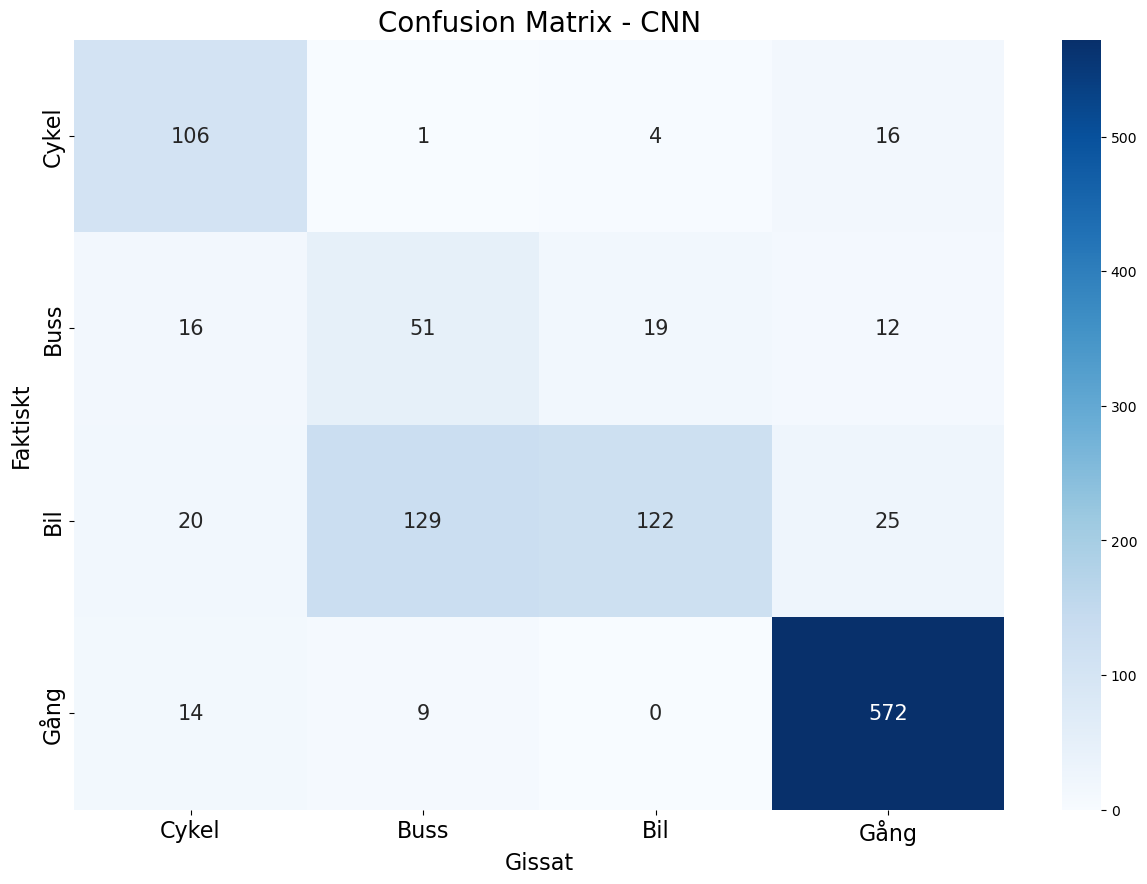


En graf över accuracy under träningen med testdata



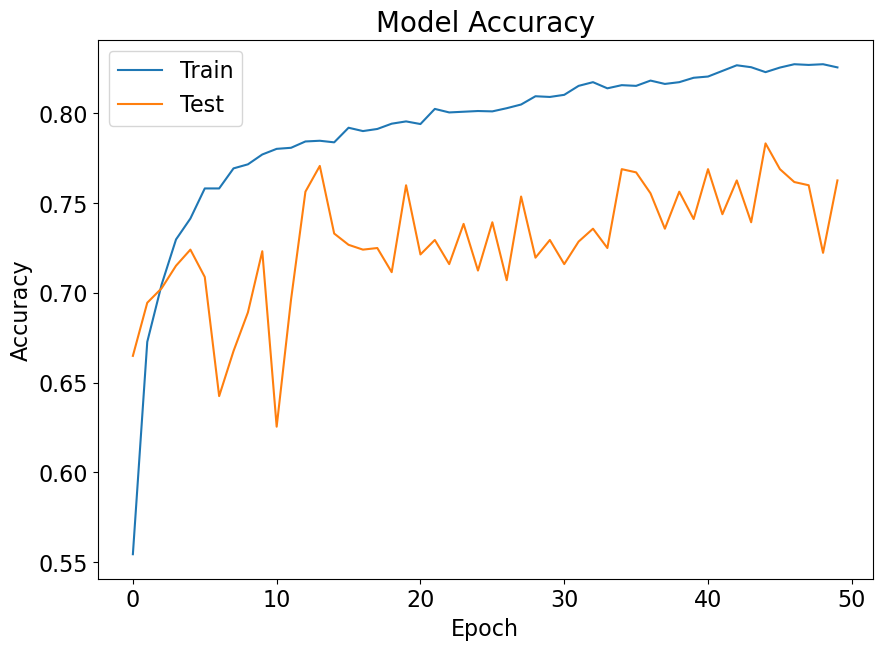


En graf över Loss under träningen med testdatan



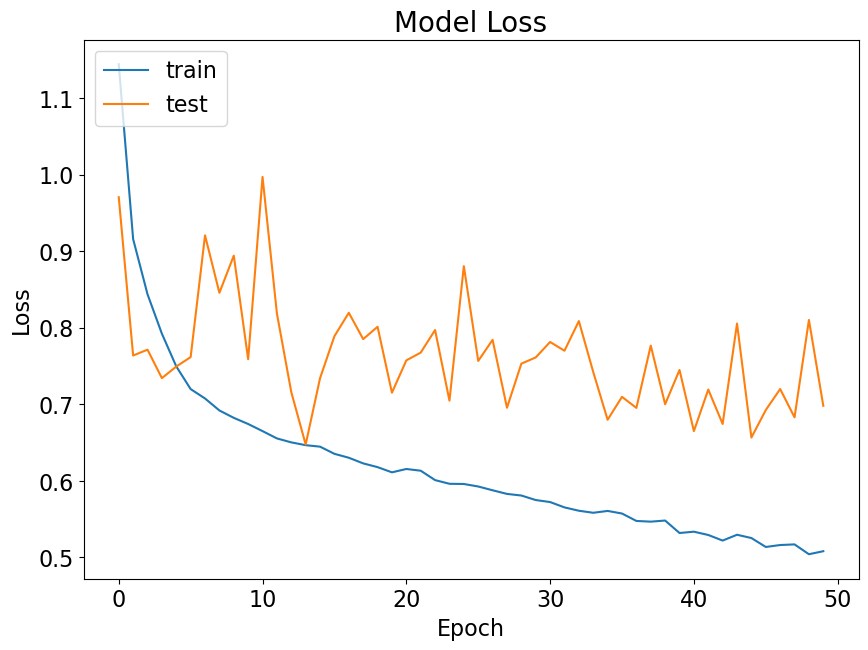

In [17]:
# Hyperparametrar för modellen, från GIT länken
# epochs och batch_size flyttade jag upp

batch_size = 128 # Kör X antal resor åt gången för att spara lite tid. 
kernel = 16 # filter för hur modellen tittar. Tittar nu på 16 sekvenspunkter samtidigt
pool = 4 # Gör modellen mer robust mot brus. komprimerar info.
stride = 1 # modellen hoppar 1 steg fram efter en sekvens.
Drop_Out = 0.4 # modellen stänger av X % av sina egna neuroner slumpmässigt mellan varje varv. Förhindrar overfitting
epochs = 50 # antal varv

# Initiera en sekventiell modell (lager läggs till i rad, nerifrån och upp)
model = Sequential()


# BLOCK 1: Extraherar vanliga särdrag (t.ex. korta accelerationer, toppfart...)
# Första faltningslagret (Conv1D) med 64 filter. input_shape definierar (fönsterstorlek, antal sensorer/features)
model.add(Conv1D(64, kernel, strides=stride, padding='same', dilation_rate = 1, input_shape=(trip_size, num_features)))
model.add(Activation("relu"))
model.add(Conv1D(64, kernel, strides=stride, padding='same', dilation_rate = 1))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling1D(pool_size=pool))

# Reglering (förhindrar overfitting genom att släppa slumpmässiga noder)
model.add(Dropout(Drop_Out))


# BLOCK 2: Kombinerar särdrag till mer komplexa mönster (t.ex. cykliska rörelser)
model.add(Conv1D(128, kernel, strides=stride, padding='same', dilation_rate = 1))
model.add(Activation("relu"))
model.add(Conv1D(128, kernel, strides=stride, padding='same', dilation_rate = 1))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling1D(pool_size=pool))

model.add(Dropout(Drop_Out))


# BLOCK 3: Djupa, abstrakta särdrag (t.ex. unika mönster för bil vs buss)
model.add(Conv1D(256, kernel, strides=stride, padding='same', dilation_rate = 1))
model.add(Activation("relu"))
model.add(Conv1D(256, kernel, strides=stride, padding='same', dilation_rate = 1))
model.add(BatchNormalization())
model.add(Activation("relu"))
model.add(MaxPooling1D(pool_size=pool))

model.add(Flatten())

model.add(Dropout(Drop_Out))

model.add(Dense(2048))
model.add(Activation("relu"))

model.add(Dropout(Drop_Out))

model.add(Dense(1024))
model.add(Activation("relu"))

# Utgångslager: num_class (4 st för Cykel, Buss, Bil, Gång) med Softmax 
# Softmax omvandlar modellens utdata till sannolikheter mellan 0 och 1 som adderas till 100%
model.add(Dense(num_class, activation='softmax'))

# Funktion för att sänka learningrate efter ett bestämt antal epochs.
EPOCHS = 100 
def scheduler(epoch, lr):
    if epoch % EPOCHS == 0 and epoch != 0:
        print("[INFO] lr is  ... ", lr/10)                
        return lr/10
    else:
        return lr

# optimizer = Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=0.0)
# optimizer = SGD(lr=0.0001, momentum=0.9, decay=1e-4, nesterov=True)
# optimizer = RMSprop(learning_rate=0.0005) - Gamla
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

callback = tf.keras.callbacks.LearningRateScheduler(scheduler)

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

hist = model.fit(Train_X, Train_Y, epochs=epochs, batch_size=batch_size, validation_data=(Test_X, Test_Y), callbacks=[callback])

# Testning av modell
pred_Y = model.predict(Test_X)
pred_Y_N = np.argmax(pred_Y, axis=1)
Pred_Y = enc.fit_transform(pred_Y_N.reshape(-1, 1))

# Transformerar om one-hot encodingen till siffror igen
Pred_Y_N = enc.inverse_transform(Pred_Y)
Test_Y_N = enc.inverse_transform(Test_Y)

# Confusion matrix och classification rapport
print()
print("Confusion matrix och classification rapport\n")
print("Klassernas ordning: 0 Cykel, 1 Buss, 2 Bil, 3 Gång")
print(confusion_matrix(Test_Y_N, Pred_Y_N))
print()
print(classification_report(Test_Y_N, Pred_Y_N))
print(accuracy_score(Test_Y_N, Pred_Y_N))

# Confusion Matrix
print()
print("CM visuellt\n")
LABELS = ['Cykel','Buss','Bil','Gång']
cm = confusion_matrix(Test_Y_N, Pred_Y_N)
bg_color = (0.88,0.85,0.95)

plt.figure(figsize=(15,10))
sns.heatmap(cm,xticklabels=LABELS, yticklabels=LABELS,annot=True, fmt="d", cmap='Blues', annot_kws={'size':15})
plt.title('Confusion Matrix - CNN', fontsize = 20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Gissat', fontsize = 16)
plt.ylabel('Faktiskt', fontsize = 16)

plt.show()

# Sammanfattning av Accuracy genom träningen
print()
print("En graf över accuracy under träningen med testdata\n")
plt.figure(figsize=(10, 7))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy', fontsize = 20)
plt.ylabel('Accuracy', fontsize = 16)
plt.xlabel('Epoch', fontsize = 16)
plt.legend(['Train', 'Test'], loc='upper left', fontsize = 16)
plt.show()

# Sammanfattning av Loss genom träningen
print()
print("En graf över Loss under träningen med testdatan\n")
plt.figure(figsize=(10, 7))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model Loss', fontsize = 20)
plt.ylabel('Loss', fontsize = 16)
plt.xlabel('Epoch', fontsize = 16)
plt.legend(['train', 'test'], loc='upper left', fontsize = 16)
plt.show()

